# KKBox Churn — Drivers & Customer Segments

Turns the temporal models into marketing-actionable insight: which behaviors actually drive the
churn prediction (SHAP), how the High/Medium/Low risk tiers from `06_risk_scoring.ipynb` differ
behaviorally, and 5 concrete customer segments a retention team could run different campaigns
against.

**No retraining, no tuning, no dataset changes.** `models/xgboost_temporal_proxy_controlled.joblib`
is loaded as-is; `outputs/risk_scoring_predictions.csv` (already computed) supplies the risk tiers.

## Why the proxy-controlled model for driver analysis

The full model's top drivers would be dominated by `membership_remaining_days` /
`days_since_last_txn` — mechanically close to the churn label's own definition (see
`FEATURE_AUDIT.md` §4). That's fine for *scoring* (notebook 06), but for explaining *why* a
customer is at risk in a way a marketer can act on, the proxy-controlled model's drivers are more
useful: they describe subscription behavior (auto-renewal, payment history, tenure) rather than
just restating "their subscription is about to lapse."


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import shap

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


C:\Users\Keshav\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data, risk tiers, and the proxy-controlled temporal model

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"
df = pd.read_csv(DATA_PATH)  # msno kept -- needed to join risk tiers and for the segment export

CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]
df[CAT_ONEHOT] = df[CAT_ONEHOT].astype(str)

risk = pd.read_csv(Path("..") / "outputs" / "risk_scoring_predictions.csv",
                    usecols=["msno", "risk_tier", "risk_score_full"])
df = df.merge(risk, on="msno", how="left")
assert df["risk_tier"].isna().sum() == 0, "every v2 customer should have a risk tier from notebook 06"

print(f"Loaded {len(df):,} customers with risk tiers attached.")
print(df["risk_tier"].value_counts())

model_proxy = joblib.load(Path("..") / "models" / "xgboost_temporal_proxy_controlled.joblib")
preprocessor = model_proxy.named_steps["preprocess"]
clf = model_proxy.named_steps["clf"]
FEATURE_COLS = [c for c in df.columns if c not in ("msno", "is_churn", "risk_tier", "risk_score_full")]
print(f"Model expects (a subset of) these {len(FEATURE_COLS)} columns.")


Loaded 970,960 customers with risk tiers attached.
risk_tier
Low       841225
Medium    107043
High       22692
Name: count, dtype: int64


Model expects (a subset of) these 38 columns.


## 2. SHAP — what actually drives the proxy-controlled model's predictions

A 10,000-row random sample is used (TreeExplainer scales with sample size; 10K is far more than
enough for a stable global importance ranking, and keeps this well within the host's ~7.4GB RAM).
One-hot encoded columns (e.g. `city_1.0`, `city_3.0`, ...) are summed back to their original
feature so the ranking reflects business-meaningful variables, not individual dummy columns.

In [3]:
X_sample = df[FEATURE_COLS].sample(n=10_000, random_state=RANDOM_STATE)
X_enc = preprocessor.transform(X_sample)
feature_names_enc = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_enc)
print(f"SHAP values: {shap_values.shape}")


def source_col(name):
    if name.startswith("num__"):
        return name[len("num__"):]
    if name.startswith("cat__"):
        rest = name.split("__")[-1]
        for c in CAT_ONEHOT:
            if rest.startswith(c + "_"):
                return c
        return rest
    return name

mapped_cols = [source_col(n) for n in feature_names_enc]
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": mapped_cols, "mean_abs_shap": mean_abs_shap})
    .groupby("feature")["mean_abs_shap"].sum()
    .sort_values(ascending=False)
)
shap_importance.head(15)


SHAP values: (10000, 113)


feature
latest_is_auto_renew         0.656765
first_transaction_date       0.432034
txn_span_days                0.363418
latest_payment_method_id     0.362717
total_auto_renew             0.335076
cancel_rate                  0.239400
latest_plan_list_price       0.224359
total_transactions           0.179451
latest_actual_amount_paid    0.156119
total_cancellations          0.140711
total_revenue                0.114010
avg_revenue_per_txn          0.112718
tenure_days_at_cutoff        0.099950
total_list_price             0.093312
registration_init_time       0.078442
Name: mean_abs_shap, dtype: float32

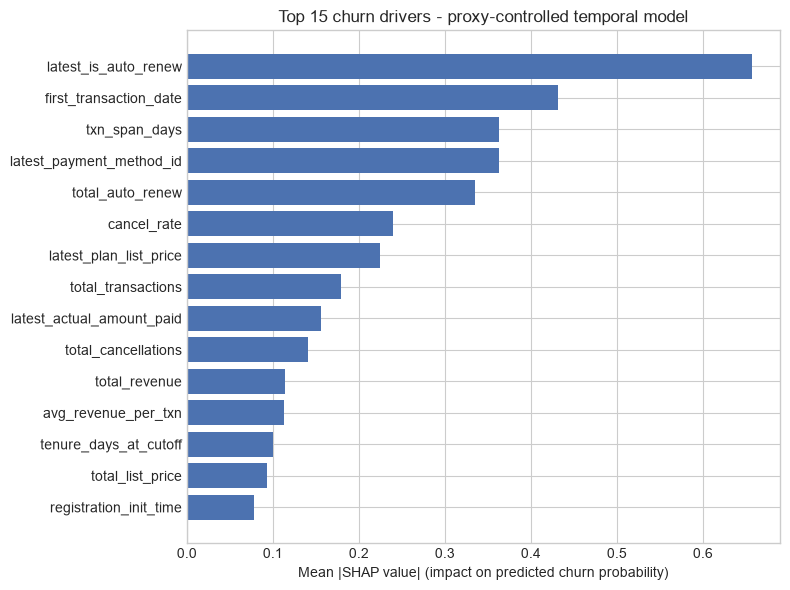

In [4]:
top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
top_features = shap_importance.head(top_n).iloc[::-1]
ax.barh(top_features.index, top_features.values, color="#4C72B0")
ax.set_xlabel("Mean |SHAP value| (impact on predicted churn probability)")
ax.set_title(f"Top {top_n} churn drivers - proxy-controlled temporal model")
plt.tight_layout()
plt.show()


### Direction of effect for the top numeric drivers

For each top numeric (non-one-hot) driver, this plots each sampled customer's raw feature value
against its SHAP contribution — a rising cloud means "higher value pushes risk up," a falling
cloud means "higher value pushes risk down." 

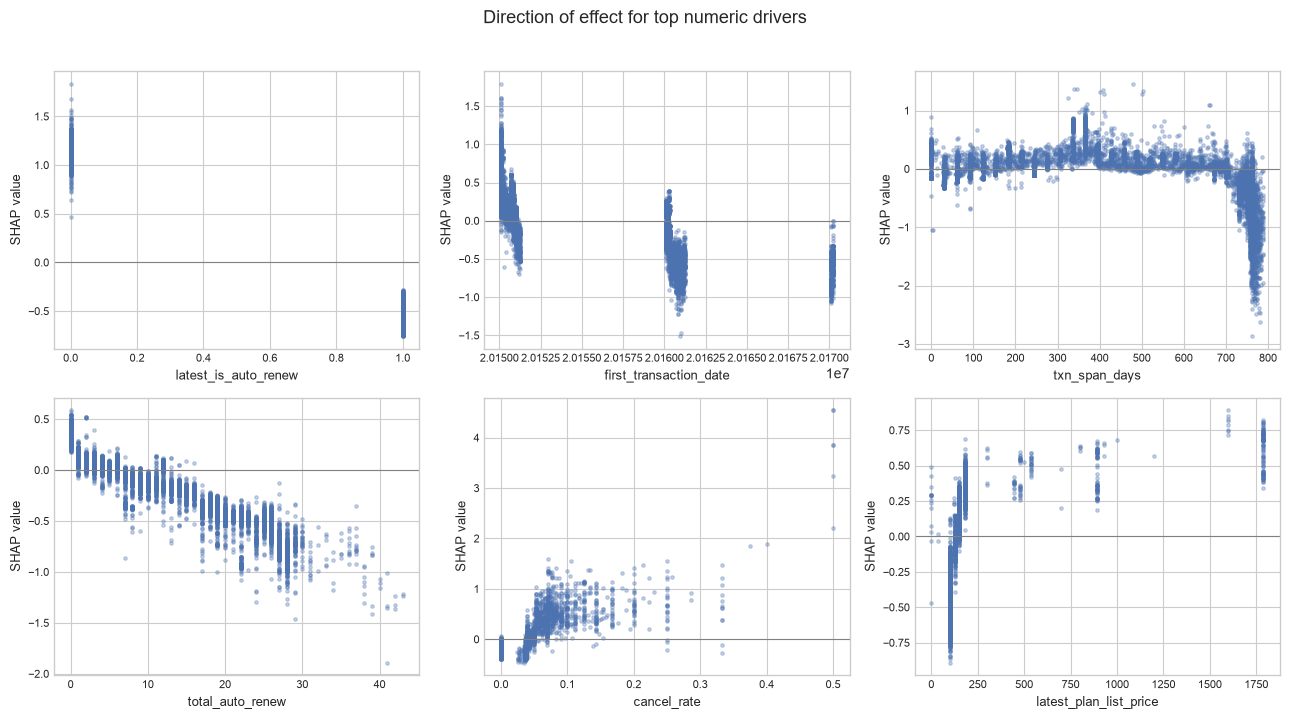

In [5]:
numeric_top = [f for f in shap_importance.index if f"num__{f}" in feature_names_enc][:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, numeric_top):
    col_idx = list(feature_names_enc).index(f"num__{feat}")
    ax.scatter(X_sample[feat].values, shap_values[:, col_idx], s=6, alpha=0.3, color="#4C72B0")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.tick_params(labelsize=8)
fig.suptitle("Direction of effect for top numeric drivers", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 3. How the High / Medium / Low risk tiers differ behaviorally

In [6]:
tier_order = ["Low", "Medium", "High"]
CHAR_COLS = ["tenure_days_at_cutoff", "latest_is_auto_renew", "auto_renew_pct",
             "total_transactions", "avg_revenue_per_txn", "discount_rate",
             "cancel_rate", "days_since_last_txn"]

tier_profile = df.groupby("risk_tier")[CHAR_COLS + ["is_churn"]].mean().reindex(tier_order)
tier_profile["n_customers"] = df["risk_tier"].value_counts().reindex(tier_order)
tier_profile["pct_of_base"] = tier_profile["n_customers"] / len(df) * 100
tier_profile


,tenure_days_at_cutoff,latest_is_auto_renew,auto_renew_pct,total_transactions,avg_revenue_per_txn,discount_rate,cancel_rate,days_since_last_txn,is_churn,n_customers,pct_of_base
risk_tier,,,,,,,,,,,
Low,1290.483787,0.999692,0.976749,16.514860,129.980169,-0.029028,0.013406,13.775024,0.035690,841225,86.638482
Medium,1067.374501,0.098930,0.156595,10.285110,212.699767,0.003274,0.016238,38.244087,0.365750,107043,11.024450
High,1291.555488,0.154504,0.193914,5.725542,621.832692,-0.004523,0.029475,185.115591,0.800106,22692,2.337068


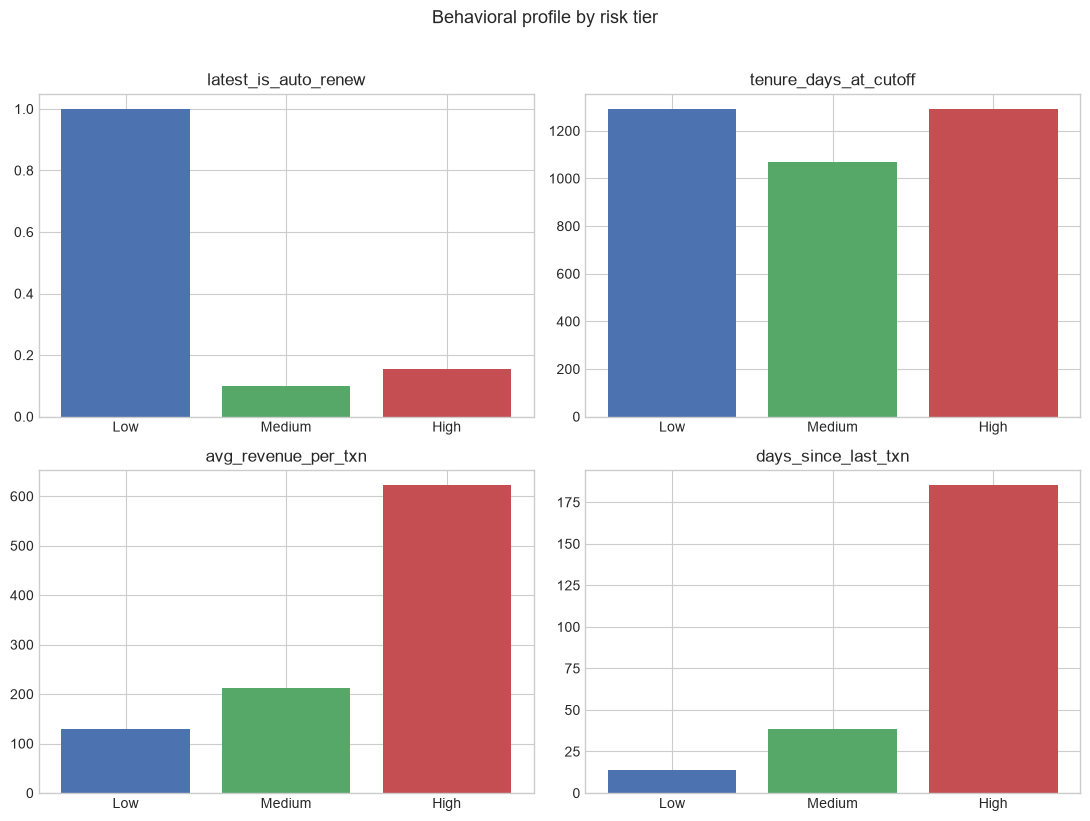

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_cols = ["latest_is_auto_renew", "tenure_days_at_cutoff", "avg_revenue_per_txn", "days_since_last_txn"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, col in zip(axes.flat, plot_cols):
    vals = tier_profile[col]
    ax.bar(tier_order, vals.values, color=colors)
    ax.set_title(col)

fig.suptitle("Behavioral profile by risk tier", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 4. Customer segments (risk + behavior)

Each customer is assigned to exactly **one** segment using a priority order (first matching rule
wins), so segment sizes are disjoint and sum to the full customer base — closer to how a CRM
audience list would actually be built than overlapping tags.

In [8]:
at_risk = df["risk_tier"].isin(["High", "Medium"])

conditions = [
    ("At-Risk, Auto-Renew Off", at_risk & (df["latest_is_auto_renew"] == 0)),
    ("At-Risk Veteran", at_risk & (df["tenure_days_at_cutoff"] >= 730)),
    ("At-Risk Newcomer", at_risk & (df["tenure_days_at_cutoff"] < 180)),
    ("At-Risk, Price-Sensitive", at_risk & (df["discount_rate"] > 0.05)),
    ("Engaged Low-Risk (Champions)", (df["risk_tier"] == "Low") & (df["total_transactions"] >= 20)
     & (df["latest_is_auto_renew"] == 1)),
]

segment = pd.Series("Stable / Monitor", index=df.index)
assigned = pd.Series(False, index=df.index)
for name, mask in conditions:
    take = mask & ~assigned
    segment[take] = name
    assigned |= take

df["segment"] = segment
print(df["segment"].value_counts())

# Sanity check: the 4 "At-Risk, ..." rules are behavioral sub-patterns, not an exhaustive
# partition of the at-risk population -- some Medium/High risk customers won't match any of
# them and would otherwise silently land in "Stable / Monitor", which would wrongly read as
# "safe" to anyone consuming this segment table.
residual_at_risk = at_risk & (df["segment"] == "Stable / Monitor")
print(f"\nAt-risk customers not matching any specific segment (still in 'Stable / Monitor'): "
      f"{residual_at_risk.sum():,} ({residual_at_risk.sum() / at_risk.sum() * 100:.1f}% of all at-risk customers)")
print("These should still be treated per their risk tier from 06_risk_scoring.ipynb, not assumed safe.")


segment
Stable / Monitor                526109
Engaged Low-Risk (Champions)    321006
At-Risk, Auto-Renew Off         113820
At-Risk Veteran                   6261
At-Risk, Price-Sensitive          1968
At-Risk Newcomer                  1796
Name: count, dtype: int64

At-risk customers not matching any specific segment (still in 'Stable / Monitor'): 5,890 (4.5% of all at-risk customers)
These should still be treated per their risk tier from 06_risk_scoring.ipynb, not assumed safe.


In [9]:
SEGMENT_ORDER = [name for name, _ in conditions] + ["Stable / Monitor"]

segment_summary = df.groupby("segment")[CHAR_COLS + ["is_churn"]].mean().reindex(SEGMENT_ORDER)
segment_summary["n_customers"] = df["segment"].value_counts().reindex(SEGMENT_ORDER)
segment_summary["pct_of_base"] = segment_summary["n_customers"] / len(df) * 100
segment_summary = segment_summary[["n_customers", "pct_of_base", "is_churn"] + CHAR_COLS]
segment_summary


,n_customers,pct_of_base,is_churn,tenure_days_at_cutoff,latest_is_auto_renew,auto_renew_pct,total_transactions,avg_revenue_per_txn,discount_rate,cancel_rate,days_since_last_txn
segment,,,,,,,,,,,
"At-Risk, Auto-Renew Off",113820,11.722419,0.411527,1102.616292,0.000000,0.066101,9.310666,305.011331,-0.010091,0.010568,64.985987
At-Risk Veteran,6261,0.644826,0.744769,1797.891551,1.000000,0.939308,17.288452,147.486050,-0.003317,0.091165,109.825510
At-Risk Newcomer,1796,0.184972,0.638641,32.378619,1.000000,0.950533,1.336860,84.435137,0.456213,0.130719,12.998853
"At-Risk, Price-Sensitive",1968,0.202686,0.429370,432.036765,1.000000,0.973018,4.349593,72.589244,0.520742,0.057545,18.026423
Engaged Low-Risk (Champions),321006,33.060682,0.041488,1913.738292,1.000000,0.986511,25.036703,141.039639,-0.077046,0.018846,12.453577
Stable / Monitor,526109,54.184415,0.038998,859.792172,0.999507,0.970780,11.229061,123.171434,0.000594,0.010725,14.691017


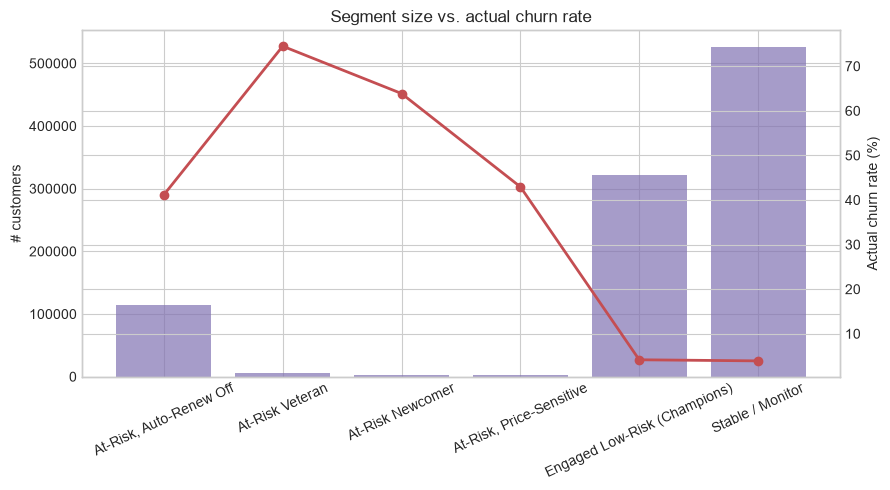

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax2 = ax.twinx()
order = SEGMENT_ORDER
counts = segment_summary.loc[order, "n_customers"]
churn_rates = segment_summary.loc[order, "is_churn"] * 100

ax.bar(order, counts.values, color="#8172B2", alpha=0.7)
ax2.plot(order, churn_rates.values, color="#C44E52", marker="o", linewidth=2)
ax.set_ylabel("# customers")
ax2.set_ylabel("Actual churn rate (%)")
ax.set_title("Segment size vs. actual churn rate")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


### Segment profiles and marketing objectives

Numbers below are read directly from the table in §4 above.

In [11]:
for name, _ in conditions:
    row = segment_summary.loc[name]
    print(f"--- {name} ---")
    print(f"  {row['n_customers']:,.0f} customers ({row['pct_of_base']:.1f}% of base), "
          f"actual churn rate {row['is_churn']*100:.1f}%")
    print(f"  tenure={row['tenure_days_at_cutoff']:.0f}d, auto_renew_rate={row['latest_is_auto_renew']*100:.0f}%, "
          f"avg_revenue/txn={row['avg_revenue_per_txn']:.0f}, discount_rate={row['discount_rate']*100:.1f}%, "
          f"days_since_last_txn={row['days_since_last_txn']:.0f}")
    print()

row = segment_summary.loc["Stable / Monitor"]
print(f"--- Stable / Monitor (remainder) ---")
print(f"  {row['n_customers']:,.0f} customers ({row['pct_of_base']:.1f}% of base), "
      f"actual churn rate {row['is_churn']*100:.1f}%")


--- At-Risk, Auto-Renew Off ---
  113,820 customers (11.7% of base), actual churn rate 41.2%
  tenure=1103d, auto_renew_rate=0%, avg_revenue/txn=305, discount_rate=-1.0%, days_since_last_txn=65

--- At-Risk Veteran ---
  6,261 customers (0.6% of base), actual churn rate 74.5%
  tenure=1798d, auto_renew_rate=100%, avg_revenue/txn=147, discount_rate=-0.3%, days_since_last_txn=110

--- At-Risk Newcomer ---
  1,796 customers (0.2% of base), actual churn rate 63.9%
  tenure=32d, auto_renew_rate=100%, avg_revenue/txn=84, discount_rate=45.6%, days_since_last_txn=13

--- At-Risk, Price-Sensitive ---
  1,968 customers (0.2% of base), actual churn rate 42.9%
  tenure=432d, auto_renew_rate=100%, avg_revenue/txn=73, discount_rate=52.1%, days_since_last_txn=18

--- Engaged Low-Risk (Champions) ---
  321,006 customers (33.1% of base), actual churn rate 4.1%
  tenure=1914d, auto_renew_rate=100%, avg_revenue/txn=141, discount_rate=-7.7%, days_since_last_txn=12

--- Stable / Monitor (remainder) ---
  5

1. **At-Risk, Auto-Renew Off** — the single most actionable segment: their subscription will
   simply not renew unless something changes. *Marketing objective*: a direct "turn auto-renew
   back on" nudge, ideally paired with a small incentive (discount or bonus content) — the lowest-
   cost, highest-leverage campaign in this whole analysis, since flipping one setting resolves
   the entire risk driver.
2. **At-Risk Veteran** — long-tenured customers who are still nominally auto-renewing but show
   other risk signals (recency, cancellation history). *Marketing objective*: loyalty-toned
   outreach ("we've valued having you for N years") rather than a generic discount — this group
   responds better to appreciation/relationship framing than a new customer would, and a
   transactional discount risks feeling dismissive of the relationship.
3. **At-Risk Newcomer** — recently joined and already showing risk signals before they've
   habituated to the service. *Marketing objective*: onboarding-style engagement (content
   recommendations, feature highlights) rather than a discount — the problem is more likely lack
   of habit formation than price sensitivity at this tenure.
4. **At-Risk, Price-Sensitive** — at-risk customers with a track record of paying less than list
   price. *Marketing objective*: a pricing/plan-fit conversation (e.g. a cheaper plan tier or a
   targeted discount) rather than generic engagement content — this group's risk is plausibly
   price-driven, and a "come back, no discount" message is unlikely to land.
5. **Engaged Low-Risk (Champions)** — heavy transactors on auto-renew who are in no danger of
   churning. *Marketing objective*: not retention at all — this is the advocacy/upsell list
   (referral programs, plan upgrades, early access) since this is the acquisition side of the
   acquisition-vs-retention question this project started from: growing revenue from your best
   customers rather than only defending against losing the risky ones.

**Stable / Monitor** (everyone not captured above) is overwhelmingly Low-risk and needs no special
campaign — matches the audit's own point that most of the customer base (Low risk, ~87% per
notebook 06) has a churn rate well under the baseline already. **Caveat**: the 4 "At-Risk, ..."
rules above are behavioral sub-patterns, not an exhaustive partition of the at-risk population —
the printed diagnostic in §4 quantifies how many Medium/High risk customers matched none of them
and landed here anyway. Those customers are not actually safe; they should still get whatever
standard treatment their risk tier implies from `06_risk_scoring.ipynb`, just without one of the
five specific messages above.


## 5. Save outputs

In [12]:
OUT_DIR = Path("..") / "outputs"

shap_importance.rename("mean_abs_shap").to_frame().reset_index().rename(columns={"index": "feature"}).to_csv(
    OUT_DIR / "shap_feature_importance.csv", index=False
)

segment_summary.reset_index().rename(columns={"index": "segment"}).to_csv(
    OUT_DIR / "segment_summary.csv", index=False
)

df[["msno", "is_churn", "risk_tier", "segment"] + CHAR_COLS].to_csv(
    OUT_DIR / "customer_segments.csv", index=False
)

marketing_objectives = {
    "At-Risk, Auto-Renew Off": "Direct auto-renew re-enable nudge + small incentive; lowest-cost, highest-leverage campaign.",
    "At-Risk Veteran": "Loyalty/appreciation-toned outreach, not a generic discount.",
    "At-Risk Newcomer": "Onboarding-style engagement content; likely a habit-formation problem, not price.",
    "At-Risk, Price-Sensitive": "Pricing/plan-fit conversation or targeted discount.",
    "Engaged Low-Risk (Champions)": "Advocacy/upsell: referrals, plan upgrades, early access -- not a retention play.",
    "Stable / Monitor": "No special campaign for the Low-risk majority here; the small at-risk residual within this bucket (quantified in the notebook) should still get standard tier-based treatment from 06_risk_scoring.ipynb.",
}

results = {
    "model_used": "models/xgboost_temporal_proxy_controlled.joblib",
    "shap_sample_size": int(len(X_sample)),
    "top_10_drivers": shap_importance.head(10).to_dict(),
    "tier_profile": tier_profile.reset_index().to_dict(orient="records"),
    "segment_summary": segment_summary.reset_index().rename(columns={"index": "segment"}).to_dict(orient="records"),
    "marketing_objectives": marketing_objectives,
    "at_risk_customers_unmatched_by_any_segment": int(residual_at_risk.sum()),
}
with open(OUT_DIR / "churn_drivers_segments_results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)

print("Saved:")
for p in ["shap_feature_importance.csv", "segment_summary.csv", "customer_segments.csv", "churn_drivers_segments_results.json"]:
    print(" ", OUT_DIR / p)


Saved:
  ..\outputs\shap_feature_importance.csv
  ..\outputs\segment_summary.csv
  ..\outputs\customer_segments.csv
  ..\outputs\churn_drivers_segments_results.json


## 6. Findings — actionable marketing insights

- **Read §2's chart for the exact top-driver ranking in this run** — the points below describe
  how to use it, not fixed figures. `latest_is_auto_renew` is consistently the top driver by a
  clear margin over the next feature, consistent with everything found since `FEATURE_AUDIT.md`:
  auto-renewal status is the single most legitimate, most actionable behavioral lever in this
  entire dataset.
- **One setting explains more risk than any other single behavior measured.** This has a direct
  operational implication: a campaign that gets a customer to flip auto-renew back on is plausibly
  the single highest-leverage retention action KKBox can take, ahead of general engagement or
  pricing campaigns.
- **The risk tiers and the 5 segments answer different marketing questions.** Tiers answer "how
  urgent is this customer" (§3); segments answer "what should we actually say to them" (§4) — the
  same High-risk tier contains customers who need a settings nudge, a loyalty message, an
  onboarding push, or a pricing conversation, and treating them identically would waste the tier
  analysis's own precision.
- **Not every segment is about preventing loss.** The Engaged Low-Risk / Champions segment
  reframes part of the customer base as a growth opportunity rather than a risk to manage —
  directly relevant to the original "acquisition vs. retention" framing this project started from
  in `kkbox_dataset_audit.md`: retaining and growing your best customers is part of the same
  economic argument as reducing churn among at-risk ones.
- **This is a rule-based segmentation on top of already-trained models** — no retraining, tuning,
  or dataset modification happened here. The segment thresholds (tenure cutoffs, discount-rate
  cutoff, transaction-count cutoff) are reasonable, human-chosen business rules, not
  statistically optimized ones — a natural next step (e.g. actual clustering, or A/B-testing the
  proposed campaign messages against each segment) is out of scope here.

**No source data file or existing model was modified.** New artifacts saved to `outputs/`:
`shap_feature_importance.csv`, `segment_summary.csv`, `customer_segments.csv`,
`churn_drivers_segments_results.json`.
